# Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from itertools import combinations


# Load Data

#### Step 1 : Import Time Related, Freq Related, and Joint Related Features

In [12]:
time_rel_features = (pd.read_pickle("../data/feature_mart/train_features.pkl")
                        .reset_index(drop = False)
                            .rename(columns = {"index":"key"})) # Time-Related Features 
freq_rel_features = (pd.read_pickle("../data/feature_mart/train_frequency_features.pkl")
                    .reset_index(drop = False)
                        .rename(columns = {"index":"key"})) # Frequency Related Features
joint_rel_features = (pd.read_pickle("../data/feature_mart/train_join_features.pkl") 
                        .reset_index(drop = False)
                            .rename(columns = {"index":"key"}))# Joint Features

In [13]:
print(f"Time Related Features: {time_rel_features.shape}")
print(f"Frequency Related Features: {freq_rel_features.shape}")
print(f"Time-Frequency Related Features: {joint_rel_features.shape}")

Time Related Features: (4890, 777)
Frequency Related Features: (4890, 649)
Time-Frequency Related Features: (4890, 649)


#### Step 2 : Preprocessing Dataset

In [14]:
try:
    assert((pd.merge(time_rel_features.drop("epoch_data_ICA", axis = 1),
            freq_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left")).shape[0] == time_rel_features.shape[0])

    train_df = (pd.merge(time_rel_features.drop("epoch_data_ICA", axis = 1),
            freq_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left"))
    
    print("====== SUCCESS : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======")
except Exception as e:
    print("====== FAILED : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======")
    


try:
    assert((pd.merge(train_df,
            joint_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left")).shape[0] == time_rel_features.shape[0])

    train_df = (pd.merge(train_df,
            joint_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left"))
    
    print("====== SUCCESS : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======")
except Exception as e:
    print("====== FAILED : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======")
    



====== SUCCESS : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======
====== SUCCESS : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======


In [15]:
del time_rel_features, freq_rel_features, joint_rel_features

In [16]:
X = train_df.drop(['key', 'subject', 'trial', 'trail_type', 'label', 'label_description',
       'shape', 'epoch_data_ICA_inds_x', "epoch_data_ICA_inds_y", "epoch_data_ICA_inds"], axis = 1) # features
y = train_df["label"] # label

print(f"Shape of X : {X.shape}")
print(f"Shape of y : {y.shape}")

Shape of X : (4890, 2048)
Shape of y : (4890,)


#### Step 3 : Splitting Dataset into Train, Validation

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, stratify= y)

print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_val.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of y_test : {y_val.shape}")

Shape of X_train : (3912, 2048)
Shape of X_test : (978, 2048)
Shape of y_train : (3912,)
Shape of y_test : (978,)


#### Step 4: Save the DataFrame

In [20]:
X_train.to_csv("../data/training/X_train.csv")
X_val.to_csv("../data/training/X_val.csv")
y_train.to_csv("../data/training/y_train.csv")
y_val.to_csv("../data/training/y_val.csv")

# Visualizing T-SNE and PCA

#### Step 1: Load Region of Interest

In [82]:
channel_info = pd.read_csv("../data/analysis/ChannelInformationInfo.csv")

region_of_interest = {
    "Region1": ["Fc1.", "Fc2.", "Fc3.", "Fc4.", "Fc5.", "Fc6."], 
    "Region2": ["C5..", "C6..", "C3..", "C4..","C1..", "C2.."],
    "Region3": ["Cp1.", "Cp2.", "Cp3.", "Cp4.", "Cp5.", "Cp6."], 
    "Region4": ["Fc3.", "Fc4.", "C5..", "C6..", "C3..", "C4..", "C1..", "C2..", "Cp3.", "Cp4."], 
    "Region5": ["Fc1.", "Fc2.", "Fc3.", "Fc4.", "Cp1.", "Cp2.", "Cp3.", "Cp4.", "C1..", "C2..", "C3..", "C4.."]
}


In [83]:
def roicolumnextractor(channel_info:pd.DataFrame, region_of_interest:dict, focus_region:str):
    try:
        assert(len(region_of_interest[focus_region]) ==
        len(channel_info[channel_info["Region"].isin(region_of_interest[focus_region])]["Region"].unique()))
        roi_col_names = channel_info[channel_info["Region"].isin(region_of_interest[focus_region])]["ColumnNames"].to_list()
        print("======= SUCCESS : ROI Column Names Extracted =========")
    except Exception as e:
        print("======= FAILED : ROI Column Names Extracted =========", e.with_traceback())

    return roi_col_names

#### Step 2: Interest of Feature

In [84]:
def FeatureInterest(channel_info: pd.DataFrame, focus_features:str):
    foi_channel_info = channel_info[channel_info["FeatureCategory"].isin(focus_features)]
    return foi_channel_info

#### Step 3 : Narrow Focus Regions


In [122]:
foi_channel_info = FeatureInterest(channel_info = channel_info, 
                focus_features= ["Time"])

roi_col_names = roicolumnextractor(channel_info=foi_channel_info, 
                   region_of_interest=region_of_interest, 
                   focus_region="Region3")

======= SUCCESS : ROI Column Names Extracted =========


In [123]:
len(roi_col_names)

72

In [124]:
y_dummy = y_train.copy()
X_dummy = X_train.loc[:, roi_col_names].copy()
print(f"Number of Features : {X_dummy.shape[1]}")

Number of Features : 72


In [125]:
def TSNE_PCA(X, y):
    # Encode categorical labels to numeric
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_
    
    # Standardize features
    #X_scaled = StandardScaler().fit_transform(X)
    X_scaled = X

    # ---- PCA ----
    pca = PCA(n_components=4, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print()
    
    # ---- t-SNE ----
    tsne = TSNE(n_components=3, random_state=42, perplexity=5, learning_rate=500)
    X_tsne = tsne.fit_transform(X_scaled)
    
    return X_pca, y_encoded, X_tsne

X_pca, y_encoded, X_tsne = TSNE_PCA(X_dummy.to_numpy(), y_dummy.to_numpy())

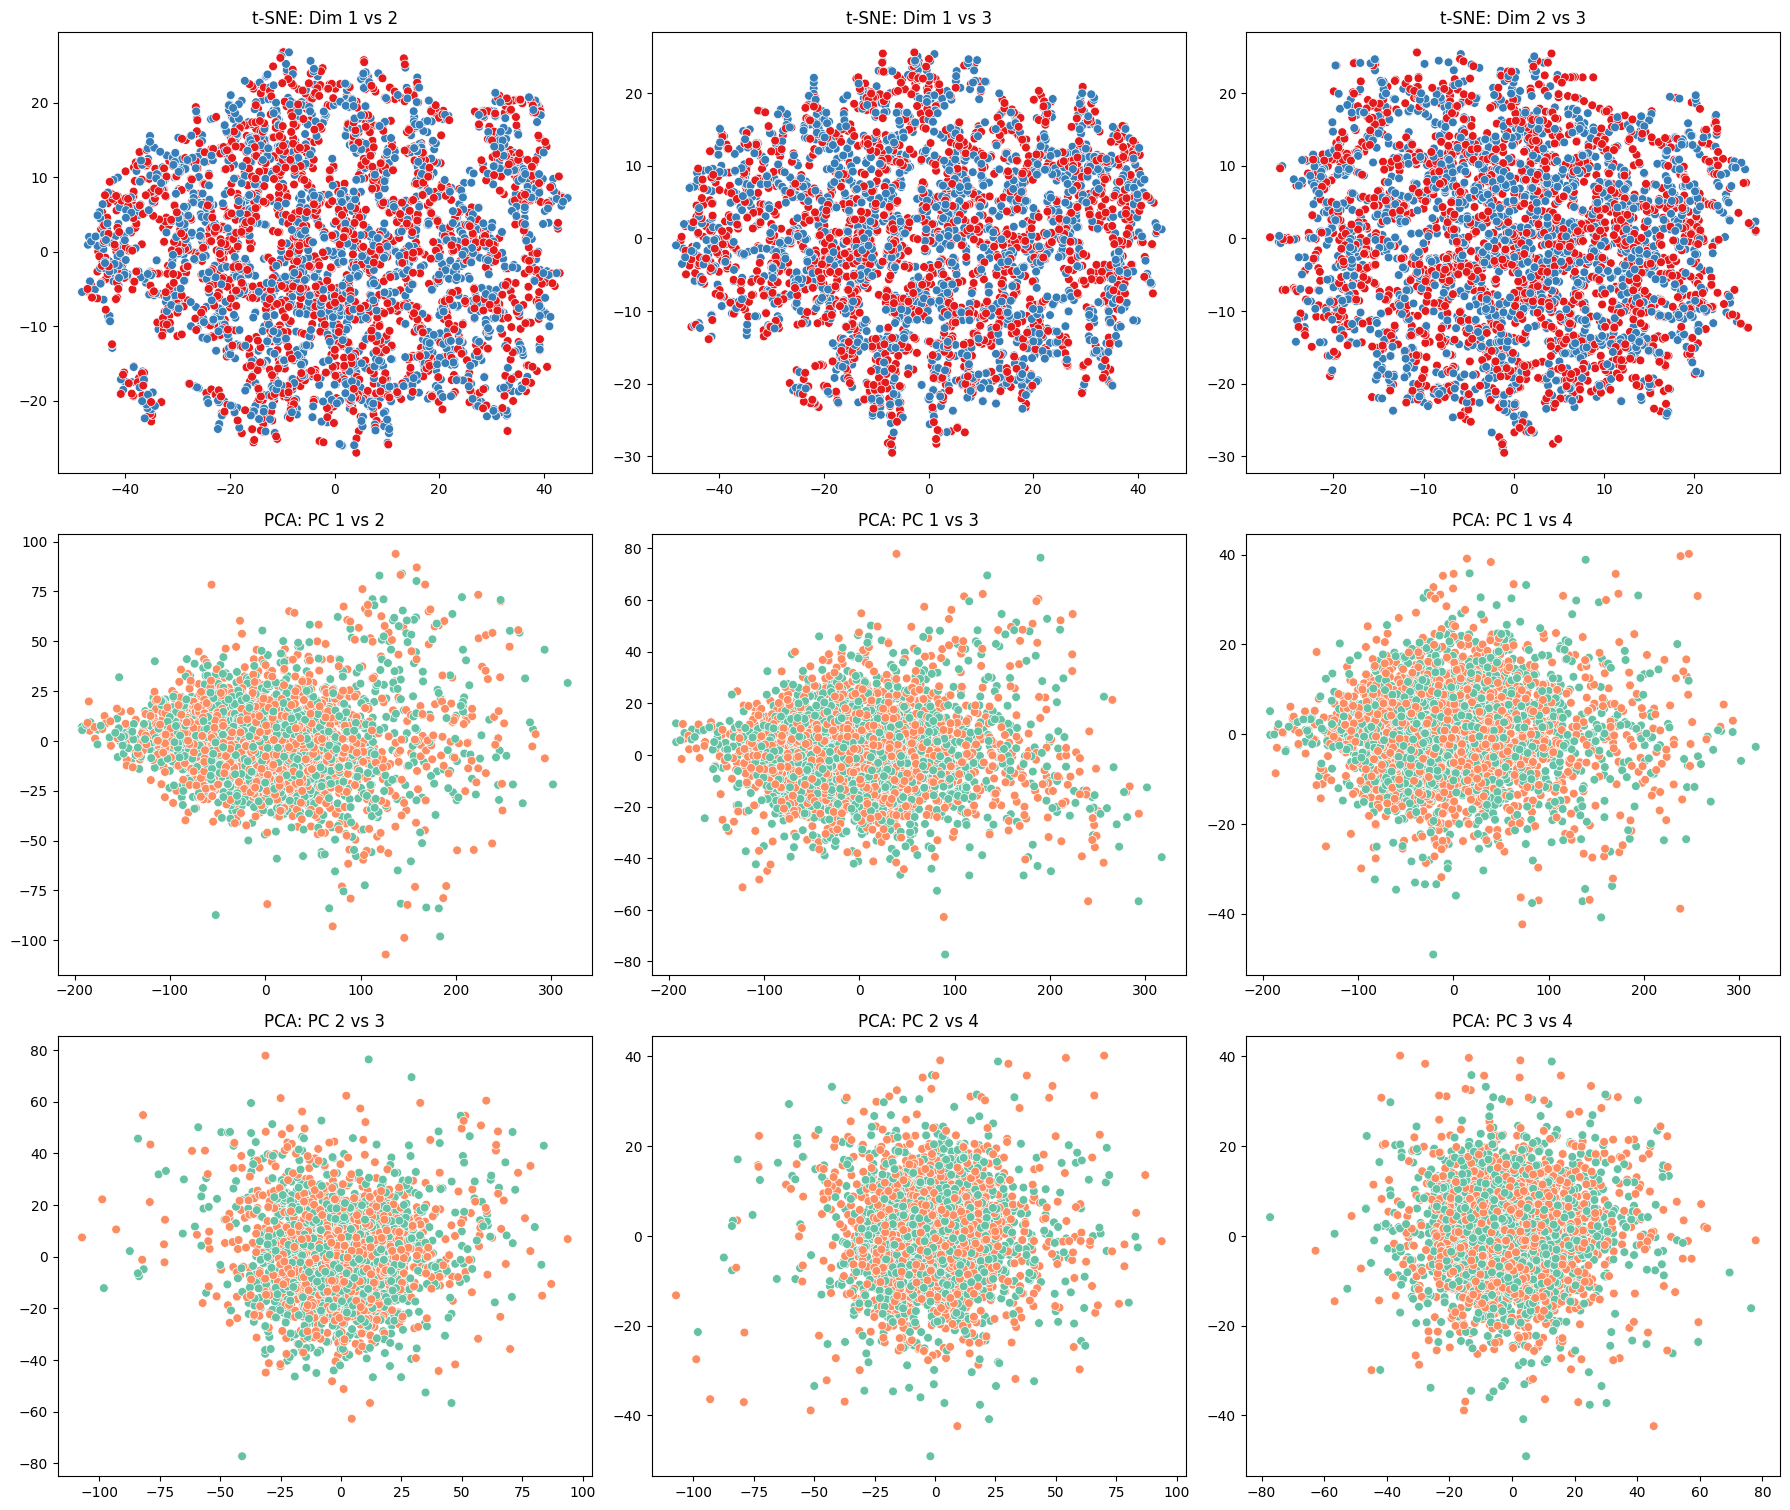

In [126]:
def dynamic_component_plots(X_tsne, X_pca, y_encoded, y_dummy):
    n_tsne = X_tsne.shape[1]
    n_pca = X_pca.shape[1]

    # --- Collect all 2D and 3D combinations ---
    tsne_2d_combs = list(combinations(range(n_tsne), 2))
    tsne_3d_combs = list(combinations(range(n_tsne), 3)) if n_tsne >= 3 else []
    pca_2d_combs = list(combinations(range(n_pca), 2))
    pca_3d_combs = list(combinations(range(n_pca), 3)) if n_pca >= 3 else []

    total_plots = len(tsne_2d_combs) + len(pca_2d_combs) + len(tsne_3d_combs) + len(pca_3d_combs)

    # --- Layout (auto grid) ---
    cols = 3 if total_plots > 3 else total_plots
    rows = (total_plots + cols - 1) // cols
    fig = plt.figure(figsize=(6 * cols, 5 * rows))

    plot_index = 1

    # --- t-SNE 2D ---
    for a, b in tsne_2d_combs:
        ax = fig.add_subplot(rows, cols, plot_index)
        sns.scatterplot(x=X_tsne[:, a], y=X_tsne[:, b], hue=y_encoded,
                        palette="Set1", s=40, ax=ax, legend=False)
        ax.set_title(f"t-SNE: Dim {a+1} vs {b+1}")
        plot_index += 1

    # --- PCA 2D ---
    for a, b in pca_2d_combs:
        ax = fig.add_subplot(rows, cols, plot_index)
        sns.scatterplot(x=X_pca[:, a], y=X_pca[:, b], hue=y_encoded,
                        palette="Set2", s=40, ax=ax, legend=False)
        ax.set_title(f"PCA: PC {a+1} vs {b+1}")
        plot_index += 1

    # Global legend for 2D plots
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 0.95))

    plt.tight_layout()
    plt.show()

# Example usage:
dynamic_component_plots(X_tsne, X_pca, y_encoded, y_dummy)


In [127]:
def plot_all_3D_tsne_pca(X_tsne, X_pca, labels):
    plots = {
        "t-SNE": X_tsne,
        "PCA": X_pca
    }

    for method_name, X in plots.items():
        n_components = X.shape[1]
        if n_components < 3:
            print(f"⚠️ {method_name} has only {n_components} components, skipping 3D plots.")
            continue

        combs = list(combinations(range(n_components), 3))

        for (a, b, c) in combs:
            fig = px.scatter_3d(
                x=X[:, a],
                y=X[:, b],
                z=X[:, c],
                color=labels,
                symbol=labels,
                title=f"{method_name}: Components {a+1}, {b+1}, {c+1}"
            )
            fig.update_traces(marker=dict(size=5, opacity=0.8))
            fig.show()

In [128]:
plot_all_3D_tsne_pca(X_tsne, X_pca, y_encoded)
